# Laboratorio de regresión - 4

|                |                  |
:----------------|------------------|
| **Nombre**     | Omar Mendoza     |
| **Fecha**      | 11/09/2026       |
| **Expediente** | 757806           |

## Modelos penalizados

Hasta ahora la función de costo que usamos para decidir qué tan bueno es nuestro modelo al momento de ajustar es:

$$ \text{RSS} = \sum_{i=1}^n e_i^2 = \sum_{i=1}^n (y_i - \hat{y_i})^2 $$

Dado que los errores obtenidos son una combinación de sesgo y varianza, puede ser que se sesgue un parámetro para minimizar el error. Esto significa que el modelo puede decidir que la salida no sea una combinación de los factores, sino una fuerte predilección sobre uno de los factores solamente. 

E.g. se quiere ajustar un modelo

$$ \hat{z} = \hat{\beta_0} + \hat{\beta_1} x + \hat{\beta_2} y $$

Se ajusta el modelo y se decide que la mejor decisión es $\hat{\beta_1} = 10000$ y $\hat{\beta_2}=50$. Considera limitaciones de problemas reales:
- Quizás los parámetros son ajustes de maquinaria que se deben realizar para conseguir el mejor producto posible, y que $10000$ sea imposible de asignar.
- Quizás los datos actuales están sesgados y sólo hacen parecer que uno de los factores importa más que el otro.

Una de las formas en las que se puede mitigar este problema es penalizando a los parámetros del modelo, cambiando la función de costo:

$$ \text{RSS}_{L2} = \sum_{i=1}^n e_i^2  + \lambda \sum_{j=1}^p \hat{\beta_j}^2 $$

El *L2* significa que se está agregando una penalización de segundo orden. Lo que hace esta penalización es que los factores ahora sólo tendrán permitido crecer si hay una reducción al menos proporcional en el error (sacrificamos sesgo, pero reducimos la varianza).

Asimismo, existe la penalización *L1*

$$ \text{RSS}_{L1} = \sum_{i=1}^n e_i^2  + \lambda \sum_{j=1}^p |\hat{\beta_j}| $$

A las penalizaciones *L2* y *L1* se les conoce también como Ridge y Lasso, respectivamente.

Para realizar una regresión con penalización de Ridge o de Lasso usamos el objeto `Ridge(alpha=?)` o `Lasso(alpha=?)` en lugar de `LinearRegression()` de `sklearn`.

Utiliza el dataset de publicidad (Advertising.csv), utiliza train-test-split de 70/30 y realiza 3 regresiones múltiples:

$$ \text{sales} = \beta_0 + \beta_1 (\text{TV}) + \beta_2 (\text{radio}) + \beta_3 (\text{newspaper}) + \epsilon $$

1. Sin penalización
2. Con penalización L2
3. Con penalización L1

¿Qué puedes observar al ajustar los valores de `alpha`? 

Compara los resultados de los coeficientes utilizando valores diferentes de $\alpha$ y los $R^2$ resultantes.



In [1]:
# Cargar los datos de publicidad y partirlos 70/30

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split

datos = pd.read_csv("Advertising.csv", index_col=0)

X = datos[["TV", "radio", "newspaper"]]
y = datos["sales"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (140, 3)
Prueba: (60, 3)


In [2]:
# Una función para ajustar un modelo y sacar sus coeficientes y R2

def resultados(modelo, nombre):
    modelo.fit(X_train, y_train)

    return {
        "modelo": nombre,
        "B0": modelo.intercept_,
        "TV": modelo.coef_[0],
        "radio": modelo.coef_[1],
        "newspaper": modelo.coef_[2],
        "R2 train": modelo.score(X_train, y_train),
        "R2 test": modelo.score(X_test, y_test),
    }

In [3]:
# 1 Sin penalización

sin_pena = pd.DataFrame([resultados(LinearRegression(), "OLS")])

sin_pena.round(4)

,modelo,B0,TV,radio,newspaper,R2 train,R2 test
0,OLS,2.8803,0.0439,0.2003,0.0018,0.9066,0.8649


In [4]:
# 2 Con penalización L2 probando varios alpha

alphas_ridge = [0.01, 1, 10, 100, 1000, 10000, 100000]

ridge = pd.DataFrame([resultados(Ridge(alpha=a), "Ridge a=%g" % a) for a in alphas_ridge])

ridge.round(4)

,modelo,B0,TV,radio,newspaper,R2 train,R2 test
0,Ridge a=0.01,2.8803,0.0439,0.2003,0.0018,0.9066,0.8649
1,Ridge a=1,2.8804,0.0439,0.2003,0.0018,0.9066,0.8649
2,Ridge a=10,2.8814,0.0439,0.2002,0.0019,0.9066,0.8649
3,Ridge a=100,2.8921,0.0439,0.1996,0.0020,0.9066,0.8653
4,Ridge a=1000,2.9960,0.0439,0.1938,0.0032,0.9062,0.8681
5,Ridge a=10000,3.8171,0.0436,0.1505,0.0109,0.8867,0.8785
6,Ridge a=100000,6.5599,0.0408,0.0482,0.0135,0.7107,0.8028


In [5]:
# 3 Con penalización L1 probando varios alpha

alphas_lasso = [0.01, 0.1, 0.5, 1, 2, 5, 10, 20]

lasso = pd.DataFrame([resultados(Lasso(alpha=a, max_iter=10000), "Lasso a=%g" % a) for a in alphas_lasso])

lasso.round(4)

,modelo,B0,TV,radio,newspaper,R2 train,R2 test
0,Lasso a=0.01,2.8817,0.0439,0.2002,0.0018,0.9066,0.8649
1,Lasso a=0.1,2.8942,0.0439,0.1999,0.0017,0.9066,0.8652
2,Lasso a=0.5,2.9502,0.0439,0.1984,0.0011,0.9065,0.8665
3,Lasso a=1,3.0202,0.0439,0.1966,0.0003,0.9064,0.8679
4,Lasso a=2,3.1411,0.0438,0.1924,0.0000,0.9059,0.8702
5,Lasso a=5,3.4878,0.0435,0.1796,0.0000,0.9024,0.8750
6,Lasso a=10,4.0658,0.0429,0.1582,0.0000,0.8901,0.8777
7,Lasso a=20,5.2216,0.0419,0.1154,0.0000,0.8406,0.8632


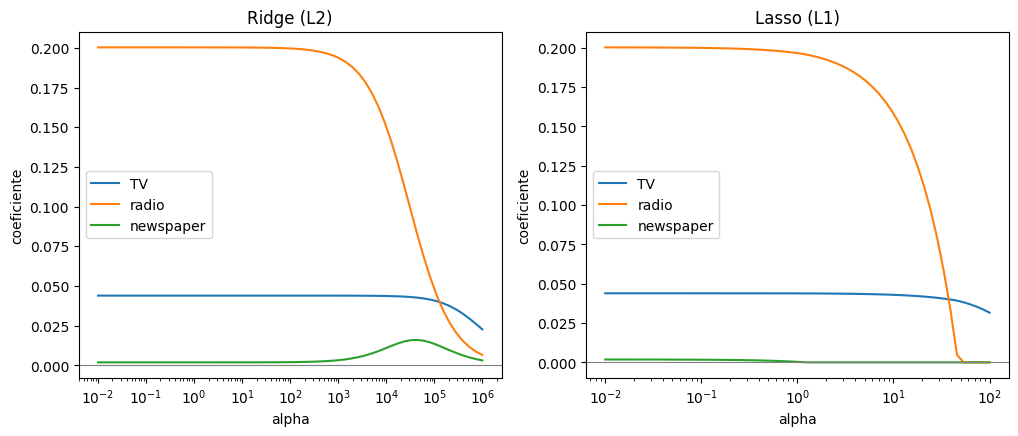

In [6]:
# Cómo se van encogiendo los coeficientes conforme sube alpha

rejilla_ridge = np.logspace(-2, 6, 60)
rejilla_lasso = np.logspace(-2, 2, 60)

coefs_ridge = np.array([Ridge(alpha=a).fit(X_train, y_train).coef_ for a in rejilla_ridge])
coefs_lasso = np.array([Lasso(alpha=a, max_iter=10000).fit(X_train, y_train).coef_ for a in rejilla_lasso])

figura, ejes = plt.subplots(1, 2, figsize=(12, 4.5))

for j, nombre in enumerate(["TV", "radio", "newspaper"]):
    ejes[0].plot(rejilla_ridge, coefs_ridge[:, j], label=nombre)
    ejes[1].plot(rejilla_lasso, coefs_lasso[:, j], label=nombre)

for eje, titulo in zip(ejes, ["Ridge (L2)", "Lasso (L1)"]):
    eje.set_xscale('log')
    eje.axhline(0, color='gray', linewidth=0.8)
    eje.set_xlabel('alpha')
    eje.set_ylabel('coeficiente')
    eje.set_title(titulo)
    eje.legend()

plt.show()

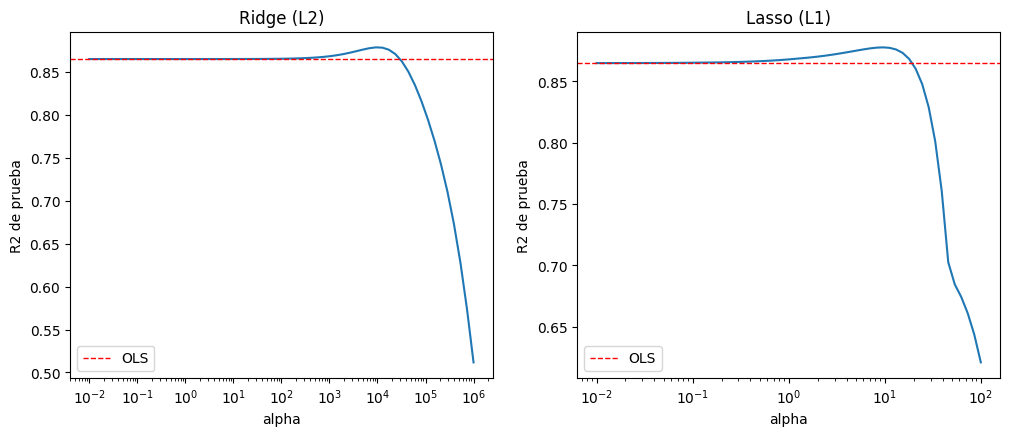

In [7]:
# Y qué pasa con el R2 de prueba conforme sube alpha

r2_ridge = [Ridge(alpha=a).fit(X_train, y_train).score(X_test, y_test) for a in rejilla_ridge]
r2_lasso = [Lasso(alpha=a, max_iter=10000).fit(X_train, y_train).score(X_test, y_test) for a in rejilla_lasso]

figura, ejes = plt.subplots(1, 2, figsize=(12, 4.5))

ejes[0].plot(rejilla_ridge, r2_ridge)
ejes[1].plot(rejilla_lasso, r2_lasso)

for eje, titulo in zip(ejes, ["Ridge (L2)", "Lasso (L1)"]):
    eje.set_xscale('log')
    eje.axhline(sin_pena["R2 test"][0], color='red', linestyle='--', linewidth=1, label='OLS')
    eje.set_xlabel('alpha')
    eje.set_ylabel('R2 de prueba')
    eje.set_title(titulo)
    eje.legend()

plt.show()

Sin penalizacion sale TV 0.0439, radio 0.2003 y newspaper 0.0018, con R2 de 0.9066 en train y 0.8649 en test

Ridge casi no mueve nada hasta que alpha es enorme, con 1000 apenas se nota y hasta 10000 o 100000 los coeficientes
se encogen de verdad. Es porque los coeficientes ya son chiquitos y la suma de sus cuadrados es casi cero, la
penalizacion no tiene mucho que castigar. Ridge encoge pero nunca llega a cero

Lasso si llega a cero, newspaper se hace 0 exacto desde alpha 2 y radio se va bajando poco a poco. Lasso va
quitando factores, primero el que menos sirve, y newspaper ya sabiamos que no aportaba

En los dos el R2 de train baja conforme sube alpha porque el modelo pierde libertad, pero el de test sube un poquito
al principio, de 0.8649 a como 0.878, o sea que penalizar tantito ayuda a generalizar. Si alpha se pasa el R2 se
cae en los dos

TV es el que mas aguanta, es el factor mas importante y ninguna de las dos penalizaciones lo mueve casi